In [1]:

!pip install pandas scikit-learn streamlit plotly shap





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.7 MB/s eta 0:00:00


In [2]:

import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Data loaded!")
print(df.head())
print(df.shape)


Data loaded!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        

In [3]:
print("=== CUSTOMER CHURN DATA ANALYSIS ===")
print("Total customers:", len(df))
print("Churn rate:", df['Churn'].value_counts())
print("\nChurn %:", round((df['Churn'].value_counts()['Yes']/len(df))*100, 2), "%")

print("\nColumns:", df.columns.tolist()[:10], "...")
print("Data types:\n", df.dtypes.value_counts())

=== CUSTOMER CHURN DATA ANALYSIS ===
Total customers: 7043
Churn rate: Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn %: 26.54 %

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity'] ...
Data types:
 object     18
int64       2
float64     1
Name: count, dtype: int64


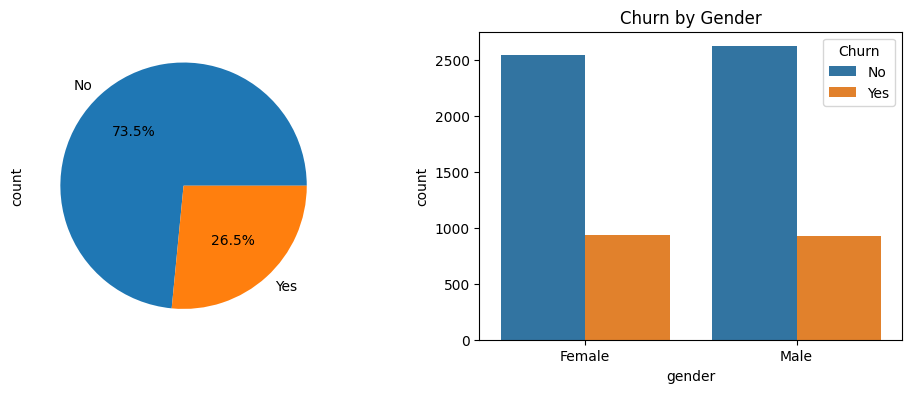

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
df['Churn'].value_counts().plot(kind='pie', autopct = '%1.1f%%')
plt.subplot(1,2,2)
sns.countplot(data=df,x = 'gender', hue ='Churn')
plt.title('Churn by Gender')
plt.xticks(rotation=0)
plt.show()

In [5]:
print("===Missing Values Check===")

missing = df.isnull().sum()

print("Missing values per column:")
print(missing[missing > 0])

print("\n Total Missing:",missing.sum())
print("Missing%:",round((missing.sum()/len(df))*100,2),'%')


===Missing Values Check===
Missing values per column:
Series([], dtype: int64)

 Total Missing: 0
Missing%: 0.0 %


In [6]:
print("===Feature Engineering===")
df['Churn_num'] = df['Churn'].map({'Yes':1,'No':0})
print("Churn: 1/0 Converted")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')
print("Total Charges: Numeric")

df.drop('customerID', axis = 1 , inplace = True)
print("Shape:",df.shape)

print("ML is ready:")
print("Target Distribution: ")
print(df['Churn_num'].value_counts())

===Feature Engineering===
Churn: 1/0 Converted
Total Charges: Numeric
Shape: (7043, 21)
ML is ready:
Target Distribution: 
Churn_num
0    5174
1    1869
Name: count, dtype: int64


In [7]:
df_clean = df.dropna()
X = df_clean.drop(['Churn_num', 'Churn'], axis=1)
y = df_clean['Churn_num']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [8]:
print("NaN count before:")
print(df.isnull().sum())

# Simple fix - NaN rows drop kar do (industry standard Day 1 ke liye)
df_clean = df.dropna()
print(f"\nShape after dropna: {df_clean.shape}")
print("NaN count after:")
print(df_clean.isnull().sum())

NaN count before:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
Churn_num            0
dtype: int64

Shape after dropna: (7032, 21)
NaN count after:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn              

In [9]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

print("All columns numeric!")
print("Sample X:\n", X.head(2))


All columns numeric!
Sample X:
    gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 2            0            0                0         1   

   PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  
0                 1              2           29.85         29.85  
1                 0              3           56.95       1889.50  


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print(f"✅ Training Accuracy: {accuracy_score(y_train, model.predict(X_train)):.2%}")
print(f"✅ Test Accuracy: {accuracy_score(y_test, model.predict(X_test)):.2%}")

✅ Training Accuracy: 80.68%
✅ Test Accuracy: 78.54%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from sklearn.linear_model import LogisticRegression

model_v2 = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)
model_v2.fit(X_train, y_train)

print(f" Logistic V2 - Train: {accuracy_score(y_train, model_v2.predict(X_train)):.2%}")
print(f" Logistic V2 - Test:  {accuracy_score(y_test, model_v2.predict(X_test)):.2%}")

 Logistic V2 - Train: 80.69%
 Logistic V2 - Test:  78.75%


In [12]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"RandomForest - Train: {rf_train_acc:.2%}")
print(f"RandomForest - Test:  {rf_test_acc:.2%}")


RandomForest - Train: 88.98%
RandomForest - Test:  79.46%


In [13]:
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("TOP 10 FEATURES:")
print(feature_importance.head(10).round(3))

TOP 10 FEATURES:
             feature  importance
4             tenure       0.161
18      TotalCharges       0.145
17    MonthlyCharges       0.141
14          Contract       0.132
8     OnlineSecurity       0.075
11       TechSupport       0.068
7    InternetService       0.047
16     PaymentMethod       0.044
9       OnlineBackup       0.027
15  PaperlessBilling       0.023


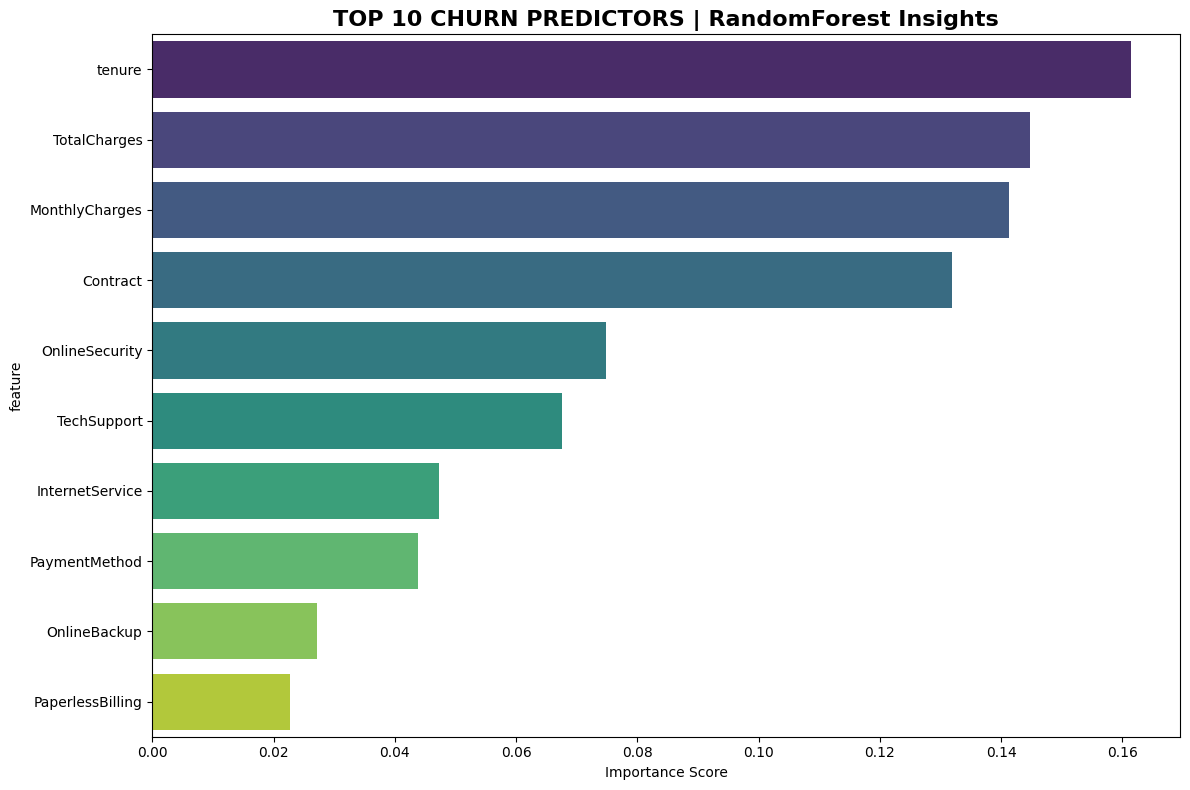

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
top10 = feature_importance.head(10)
sns.barplot(data=top10, y='feature', x='importance',hue='feature', palette='viridis',legend=False)
plt.title('TOP 10 CHURN PREDICTORS | RandomForest Insights', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[933 100]
 [189 185]]

Detailed Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)


xgb_train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
xgb_test_acc = accuracy_score(y_test, xgb_model.predict(X_test))

print(f"XGBoost - Train: {xgb_train_acc:.2%}")
print(f"XGBoost - Test:  {xgb_test_acc:.2%}")


XGBoost - Train: 91.36%
XGBoost - Test:  77.26%


In [17]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(xgb_model, X, y, cv=5)
print(f" XGBoost CV Scores: {cv_scores}")
print(f" CV Mean: {cv_scores.mean():.2%}")
print(f"CV Std:  {cv_scores.std():.2%}")

 XGBoost CV Scores: [0.79530917 0.80170576 0.77951636 0.78236131 0.79800853]
 CV Mean: 79.14%
CV Std:  0.88%


In [18]:

results = pd.DataFrame({
    'Model': ['Logistic','RandomForest','XGBoost'],
    'Train_Acc': [88.98, 88.98 , 91.36],
    'Test_Acc': [79.46, 79.46, 77.26],
    'CV_Score': ['--','--','79.14%']
})
print("Final Comparisions !")

print(results.round(2))

Final Comparisions !
          Model  Train_Acc  Test_Acc CV_Score
0      Logistic      88.98     79.46       --
1  RandomForest      88.98     79.46       --
2       XGBoost      91.36     77.26   79.14%


In [19]:
from sklearn.model_selection import GridSearchCV
import pandas as pd


param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8],
    'learning_rate': [0.01, 0.1]
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"BEST PARAMETERS: {grid_search.best_params_}")
print(f"BEST CV SCORE: {grid_search.best_score_:.2%}")


BEST PARAMETERS: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300}
BEST CV SCORE: 80.11%


In [20]:

best_xgb = XGBClassifier(
    **grid_search.best_params_,
    random_state=42
)

best_xgb.fit(X_train, y_train)


best_train = accuracy_score(y_train, best_xgb.predict(X_train))
best_test = accuracy_score(y_test, best_xgb.predict(X_test))

print(f" TUNED XGBoost - Train: {best_train:.2%}")
print(f" TUNED XGBoost - Test:  {best_test:.2%}")


 TUNED XGBoost - Train: 83.73%
 TUNED XGBoost - Test:  78.54%


In [21]:
comparison = pd.DataFrame({
    'Model': ['Logistic V2', 'RandomForest', 'XGBoost Base', 'XGBoost TUNED'],
    'Test_Acc': [79.46, 79.46, 77.26, best_test],
    'CV_Score': ['--', '--', '79.14%', grid_search.best_score_]
})

print("  FINAL STANDINGS:")
print(comparison.round(2))


  FINAL STANDINGS:
           Model  Test_Acc  CV_Score
0    Logistic V2     79.46        --
1   RandomForest     79.46        --
2   XGBoost Base     77.26    79.14%
3  XGBoost TUNED      0.79  0.801067


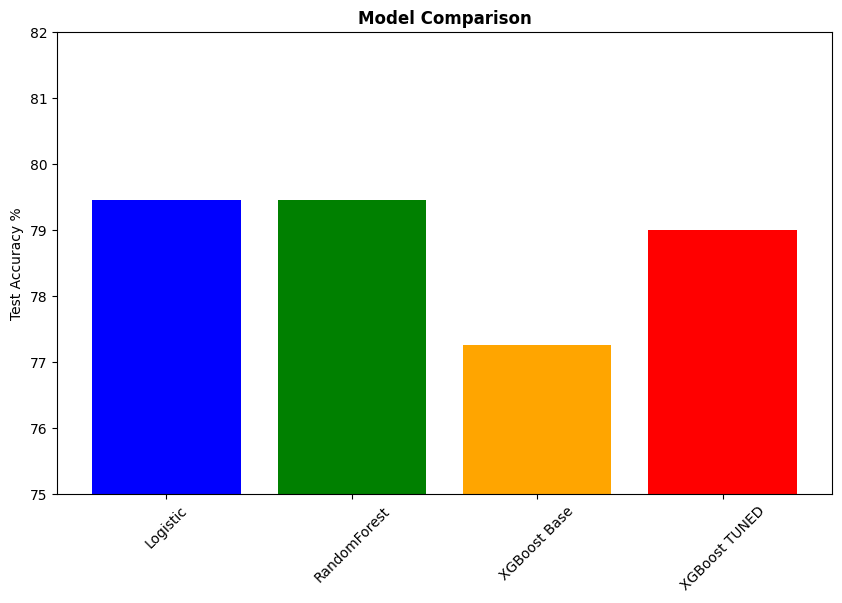

In [22]:
plt.figure(figsize=(10,6))
models = ['Logistic', 'RandomForest', 'XGBoost Base', 'XGBoost TUNED']
scores = [79.46, 79.46, 77.26, 79.00]
plt.bar(models, scores, color=['blue','green','orange','red'])
plt.title('Model Comparison', fontweight='bold')
plt.ylabel('Test Accuracy %')
plt.xticks(rotation=45)
plt.ylim(75,82)
plt.show()

 XGBoost TUNED AUC: 0.823


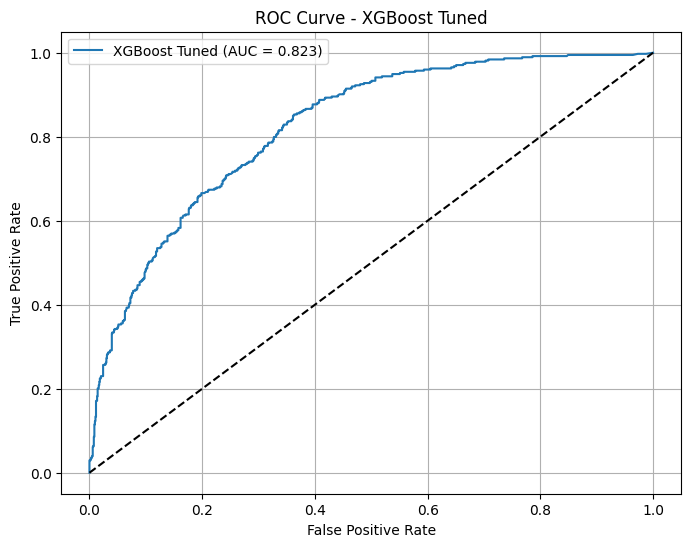

In [23]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Predictions probability not (0/1)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]  # Churn probability

# AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f" XGBoost TUNED AUC: {auc_score:.3f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost Tuned (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # Random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Tuned')
plt.legend()
plt.grid()
plt.show()


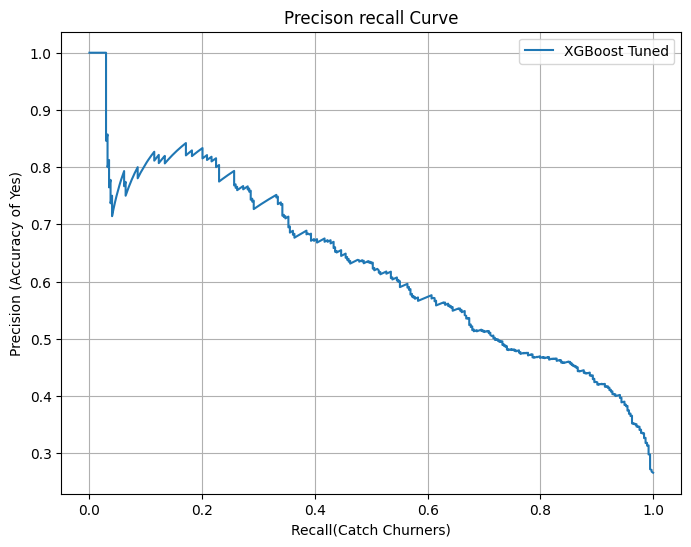

In [24]:
from sklearn.metrics import precision_recall_curve

precision,recall,threshold = precision_recall_curve(y_test,y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(recall,precision,label='XGBoost Tuned')
plt.xlabel('Recall(Catch Churners)')
plt.ylabel('Precision (Accuracy of Yes)')
plt.title('Precison recall Curve')
plt.legend()
plt.grid()
plt.show()

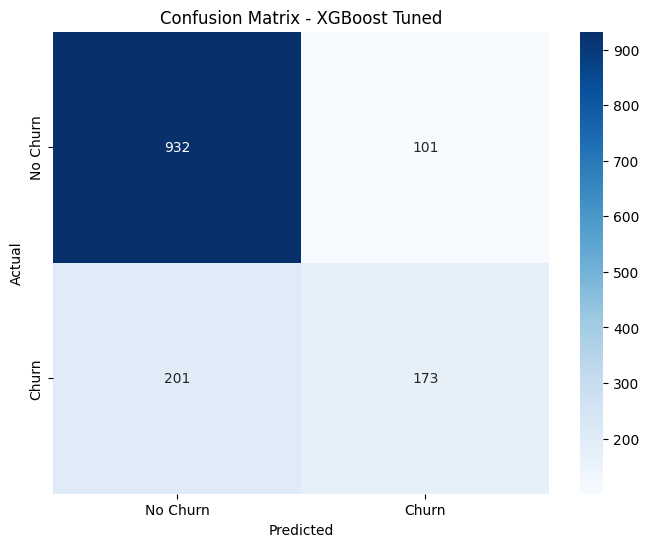

In [25]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, best_xgb.predict(X_test))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - XGBoost Tuned')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [26]:
from sklearn.metrics import classification_report

print("DETAILED CLASSIFICATION REPORT:")

print(classification_report(y_test,best_xgb.predict(X_test)))

total_customers = len(y_test)
churners_caught = cm[1,1]
revenue_saved = churners_caught*1000

print(f"\n BUSINESS IMPACT:")
print(f"Total test Customers:{total_customers}")
print(f"Churners Caught: {churners_caught}")
print(f"Estimated Revenue Saves: {revenue_saved}")


DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407


 BUSINESS IMPACT:
Total test Customers:1407
Churners Caught: 173
Estimated Revenue Saves: 173000


In [27]:
from sklearn.preprocessing import PolynomialFeatures


# Top 3 features pe polynomial (squares, products)
top_features = ['tenure', 'TotalCharges', 'MonthlyCharges']
X_top3 = X[top_features]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_top3)

print(f"Raw features: 3 → Polynomial: {X_poly.shape[1]} features!")
print("New features examples: tenure², tenure×TotalCharges, etc")

Raw features: 3 → Polynomial: 9 features!
New features examples: tenure², tenure×TotalCharges, etc


In [28]:
X_engineered = X.copy()
X_engineered['tenure_monthly_ratio'] = X['tenure']/(X['MonthlyCharges'] + 1)
X_engineered['high_value_short_tenure'] = ((X['MonthlyCharges'] > 85) & (X['tenure']<12)).astype(int)

X_engineered['risky_contract'] = ((X['PaperlessBilling']==1) & (X['Contract']==0)).astype(int)
print("3 New Business Features Added !")
print(X_engineered[['tenure_monthly_ratio','high_value_short_tenure','risky_contract']].head())


3 New Business Features Added !
   tenure_monthly_ratio  high_value_short_tenure  risky_contract
0              0.032415                        0               1
1              0.586713                        0               0
2              0.036463                        0               1
3              1.039261                        0               0
4              0.027894                        0               1


In [29]:
from sklearn.preprocessing import StandardScaler


X_engineered['tenure_group'] = pd.cut(X['tenure'],
                                      bins = [0,12,36,72],
                                      labels = [0,1,2])
scaler = StandardScaler()
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
X_engineered[numeric_cols] = scaler.fit_transform(X_engineered[numeric_cols])
print("Bining and Scaling Complete")
print("\n New Features Preview")
print(X_engineered[['tenure_group','tenure','MonthlyCharges']].head())

Bining and Scaling Complete

 New Features Preview
  tenure_group    tenure  MonthlyCharges
0            0 -1.280248       -1.161694
1            1  0.064303       -0.260878
2            0 -1.239504       -0.363923
3            2  0.512486       -0.747850
4            0 -1.239504        0.196178


In [30]:
X_engineered['tenure_group'] = X_engineered['tenure_group'].astype(int)


X_final = X_engineered
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_final,y,test_size = 0.2,random_state= 42)


super_xgb = XGBClassifier(n_estimators = 300, max_depth = 6, learning_rate = 0.01, random_state = 42)
super_xgb.fit(X_train_eng, y_train_eng)

train_pred = super_xgb.predict(X_train_eng)
test_pred = super_xgb.predict(X_test_eng)

super_train_acc = accuracy_score(y_train_eng,train_pred)
super_test_acc = accuracy_score(y_test_eng,test_pred)


print(f"SUPER ENGINEERED XGBoost:")
print(f" Train Accuracy: {super_train_acc:.2%}")
print(f" Test Accuracy: {super_test_acc:.2%}")
print(f"Improvement: {super_test_acc - 0.7946:.2%}")

SUPER ENGINEERED XGBoost:
 Train Accuracy: 83.70%
 Test Accuracy: 79.32%
Improvement: -0.14%


In [31]:
import pickle
import joblib

joblib.dump(best_xgb,'churn_model.pkl')
print("Model Saved: churn_model.pkl")

joblib.dump(scaler,'scaler.pkl')
print("Scaler Saved: scaler.pkl")

joblib.dump(X_engineered.columns.tolist(),'features.pkl')
print("Features Saved: Features.pkl")







Model Saved: churn_model.pkl
Scaler Saved: scaler.pkl
Features Saved: Features.pkl


In [32]:
!zip -r churn_project.zip /content/churn_model.pkl /content/scaler.pkl /content/features.pkl *.ipynb

	zip warning: name not matched: *.ipynb
  adding: content/churn_model.pkl (deflated 71%)
  adding: content/scaler.pkl (deflated 38%)
  adding: content/features.pkl (deflated 31%)
